In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [82]:
df = pd.read_csv("Superstore.csv")

In [3]:
df.columns = df.columns.str.replace(" ", "_")


In [4]:
df.info

<bound method DataFrame.info of       Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer_ID     Customer_Name    Segment        Country             City  \
0       CG-12520      

In [5]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [6]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales'],
      dtype='object')

In [7]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], dayfirst=True)


In [8]:
# ==========================================
# Feature Engineering 1
# Calculate the number of days taken to ship an order
# ==========================================

df["Shipping_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days

# Validation
df["Shipping_Days"].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping_Days, dtype: float64

In [9]:
# ==========================================
# Feature Engineering
# Create Order Year
# ==========================================

df["Order_Year"] = df["Order_Date"].dt.year

In [10]:
# ==========================================
# Feature Engineering 2
# Extract Order Month
# ==========================================

df["Order_Month"] = df["Order_Date"].dt.month

# Validation
print(df["Order_Month"].dtype)
print(df["Order_Month"].value_counts().sort_index())

int32
Order_Month
1      366
2      297
3      680
4      657
5      725
6      691
7      697
8      693
9     1354
10     809
11    1449
12    1382
Name: count, dtype: int64


In [11]:
# ==========================================
# Feature Engineering 3
# Extract Month Name
# ==========================================

df["Month_Name"] = df["Order_Date"].dt.month_name()

# Validation
print(df["Month_Name"].value_counts())

Month_Name
November     1449
December     1382
September    1354
October       809
May           725
July          697
August        693
June          691
March         680
April         657
January       366
February      297
Name: count, dtype: int64


In [12]:
# ==========================================
# Feature Engineering 4
# Extract Quarter
# ==========================================

df["Order_Quarter"] = df["Order_Date"].dt.quarter

# Validation
print(df["Order_Quarter"].value_counts().sort_index())

Order_Quarter
1    1343
2    2073
3    2744
4    3640
Name: count, dtype: int64


In [13]:
# ==========================================
# Feature Engineering 5
# Extract Day Name
# ==========================================

df["Day_Name"] = df["Order_Date"].dt.day_name()

# Validation
print(df["Day_Name"].value_counts())

Day_Name
Tuesday      1889
Saturday     1786
Sunday       1695
Monday       1593
Wednesday    1229
Friday       1067
Thursday      541
Name: count, dtype: int64


In [14]:
# ==========================================
# Feature Engineering 6
# Weekend Indicator
# ==========================================

df["Is_Weekend"] = df["Order_Date"].dt.dayofweek >= 5

# Validation
print(df["Is_Weekend"].value_counts())

Is_Weekend
False    6319
True     3481
Name: count, dtype: int64


In [15]:
# ==========================================
# Feature Engineering 7
# Order Week Number
# ==========================================

df["Order_Week"] = df["Order_Date"].dt.isocalendar().week

# Validation
print(df["Order_Week"].value_counts().sort_index())

Order_Week
1      70
2      69
3      84
4      77
5     116
6      66
7      86
8      65
9     106
10    141
11    163
12    160
13    146
14    157
15    173
16    148
17    132
18    170
19    152
20    154
21    163
22    175
23    149
24    195
25    161
26    149
27    162
28    162
29    163
30    160
31    103
32    169
33    144
34    190
35    240
36    287
37    345
38    340
39    256
40    204
41    169
42    184
43    164
44    279
45    352
46    327
47    371
48    370
49    358
50    257
51    304
52    254
53     59
Name: count, dtype: Int64


In [16]:
# ==========================================
# KPI 1: Top 10 Customers by Number of Orders
# ==========================================

top_customers_orders = (
    df.groupby(["Customer_ID", "Customer_Name"])["Order_ID"]
      .nunique()
      .reset_index(name="Total_Orders")
      .sort_values(by="Total_Orders", ascending=False)
)

top_customers_orders.head(10)

,Customer_ID,Customer_Name,Total_Orders
275,EP-13915,Emily Phan,17
791,ZC-21910,Zuschuss Carroll,13
147,CK-12205,Chloris Kastensmidt,13
356,JE-15745,Joel Eaton,13
591,PG-18820,Patrick Gardner,13
691,SH-19975,Sally Hughsby,12
653,RP-19390,Resi Pölking,12
694,SJ-20125,Sanjit Jacobs,12
99,BP-11095,Bart Pistole,12
576,NS-18640,Noel Staavos,12


In [17]:
# ==========================================
# KPI 2: Top 10 Customers by Sales
# ==========================================

top_customers_sales = (
    df.groupby(["Customer_ID", "Customer_Name"])["Sales"]
      .sum()
      .reset_index(name="Total_Sales")
      .sort_values(by="Total_Sales", ascending=False)
)

top_customers_sales.head(10)

,Customer_ID,Customer_Name,Total_Sales
700,SM-20320,Sean Miller,25043.050
741,TC-20980,Tamara Chand,19052.218
621,RB-19360,Raymond Buch,15117.339
730,TA-21385,Tom Ashbrook,14595.620
6,AB-10105,Adrian Barton,14473.571
434,KL-16645,Ken Lonsdale,14175.229
669,SC-20095,Sanjit Chand,14142.334
327,HL-15040,Hunter Lopez,12873.298
683,SE-20110,Sanjit Engle,12209.438
131,CC-12370,Christopher Conant,12129.072


In [18]:
# ==========================================
# KPI 3A: Sales by Category
# ==========================================

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .reset_index(name="Total_Sales")
      .sort_values(by="Total_Sales", ascending=False)
)

category_sales

,Category,Total_Sales
2,Technology,827455.8730
0,Furniture,728658.5757
1,Office Supplies,705422.3340


In [19]:
# ==========================================
# KPI 3B: Orders by Category
# ==========================================

category_orders = (
    df.groupby("Category")["Order_ID"]
      .nunique()
      .reset_index(name="Total_Orders")
      .sort_values(by="Total_Orders", ascending=False)
)

category_orders

,Category,Total_Orders
1,Office Supplies,3676
0,Furniture,1727
2,Technology,1519


In [20]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Shipping_Days', 'Order_Year', 'Order_Month',
       'Month_Name', 'Order_Quarter', 'Day_Name', 'Is_Weekend', 'Order_Week'],
      dtype='object')

In [21]:
# ==========================================
# KPI 4A: Sales by Sub-Category (Grouped by Category)
# ==========================================

subcategory_sales = (
    df.groupby(["Category", "Sub-Category"])["Sales"]
      .sum()
      .reset_index()
      .rename(columns={"Sales": "Total_Sales"})
      .sort_values(by=["Category", "Total_Sales"], ascending=[False, False])
)

subcategory_sales




,Category,Sub-Category,Total_Sales
16,Technology,Phones,327782.4480
15,Technology,Machines,189238.6310
13,Technology,Accessories,164186.7000
14,Technology,Copiers,146248.0940
11,Office Supplies,Storage,219343.3920
6,Office Supplies,Binders,200028.7850
4,Office Supplies,Appliances,104618.4030
10,Office Supplies,Paper,76828.3040
12,Office Supplies,Supplies,46420.3080
5,Office Supplies,Art,26705.4100


In [22]:
# ==========================================
# KPI 4B: Orders by Sub-Category (Grouped by Category)
# ==========================================

subcategory_orders = (
    df.groupby(["Category", "Sub-Category"])["Order_ID"]
      .nunique()
      .reset_index()
      .rename(columns={"Order_ID": "Total_Orders"})
      .sort_values(by=["Category", "Total_Orders"], ascending=[True, False])
)

subcategory_orders

,Category,Sub-Category,Total_Orders
2,Furniture,Furnishings,855
1,Furniture,Chairs,566
3,Furniture,Tables,302
0,Furniture,Bookcases,222
6,Office Supplies,Binders,1291
10,Office Supplies,Paper,1163
11,Office Supplies,Storage,764
5,Office Supplies,Art,720
4,Office Supplies,Appliances,444
9,Office Supplies,Labels,340


In [23]:

# ==========================================
# KPI 4B: Summary of Sub-Category Performance (Grouped by Category)
# ==========================================
subcategory_summary = pd.merge(
    subcategory_sales,
    subcategory_orders,
    on=["Category", "Sub-Category"]
)

subcategory_summary

,Category,Sub-Category,Total_Sales,Total_Orders
0,Technology,Phones,327782.4480,803
1,Technology,Machines,189238.6310,112
2,Technology,Accessories,164186.7000,702
3,Technology,Copiers,146248.0940,66
4,Office Supplies,Storage,219343.3920,764
5,Office Supplies,Binders,200028.7850,1291
6,Office Supplies,Appliances,104618.4030,444
7,Office Supplies,Paper,76828.3040,1163
8,Office Supplies,Supplies,46420.3080,181
9,Office Supplies,Art,26705.4100,720


In [24]:
# ==========================================
# KPI 5A: Top 5 Products by Sales in Each Category
# ==========================================

top_products_sales = (
    df.groupby(["Category", "Sub-Category", "Product_ID", "Product_Name"])["Sales"]
      .sum()
      .reset_index(name="Total_Sales")
)

top5_products_sales = (
    top_products_sales
    .sort_values(["Category", "Total_Sales"], ascending=[True, False])
    .groupby("Category")
    .head(5)
)

top5_products_sales

,Category,Sub-Category,Product_ID,Product_Name,Total_Sales
82,Furniture,Chairs,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870.5760
49,Furniture,Bookcases,FUR-BO-10004834,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.9656
363,Furniture,Tables,FUR-TA-10003473,Bretford Rectangular Conference Table Tops,12995.2915
69,Furniture,Chairs,FUR-CH-10001215,Global Troy Executive Leather Low-Back Tilter,12975.3820
123,Furniture,Chairs,FUR-CH-10004287,SAFCO Arco Folding Chair,11572.7800
787,Office Supplies,Binders,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.3840
701,Office Supplies,Binders,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,19823.4790
667,Office Supplies,Binders,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,19024.5000
858,Office Supplies,Binders,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.0680
1442,Office Supplies,Supplies,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,17030.3120


In [25]:
# ==========================================
# KPI 5B: Top 5 Products by Orders in Each Category
# ==========================================

top_products_orders = (
    df.groupby(["Category", "Sub-Category", "Product_ID", "Product_Name"])["Order_ID"]
      .nunique()
      .reset_index(name="Total_Orders")
)

top5_products_orders = (
    top_products_orders
    .sort_values(["Category", "Total_Orders"], ascending=[True, False])
    .groupby("Category")
    .head(5)
)

top5_products_orders

,Category,Sub-Category,Product_ID,Product_Name,Total_Orders
95,Furniture,Chairs,FUR-CH-10002647,"Situations Contoured Folding Chairs, 4/Set",15
99,Furniture,Chairs,FUR-CH-10002880,"Global High-Back Leather Tilter, Burgundy",14
112,Furniture,Chairs,FUR-CH-10003774,"Global Wood Trimmed Manager's Task Chair, Khaki",14
123,Furniture,Chairs,FUR-CH-10004287,SAFCO Arco Folding Chair,13
333,Furniture,Tables,FUR-TA-10001095,Chromcraft Round Conference Tables,13
704,Office Supplies,Binders,OFF-BI-10001524,GBC Premium Transparent Covers with Diagonal L...,14
653,Office Supplies,Binders,OFF-BI-10000145,Zipper Ring Binder Pockets,13
659,Office Supplies,Binders,OFF-BI-10000301,GBC Instant Report Kit,13
682,Office Supplies,Binders,OFF-BI-10000977,Ibico Plastic Spiral Binding Combs,13
818,Office Supplies,Binders,OFF-BI-10004140,Avery Non-Stick Binders,13


In [26]:
# ==========================================
# KPI 6A: Bottom 5 Products by Sales (Each Category)
# ==========================================

bottom5_products_sales = (
    top_products_sales
    .sort_values(["Category", "Total_Sales"], ascending=[True, True])
    .groupby("Category")
    .head(5)
)

bottom5_products_sales

,Category,Sub-Category,Product_ID,Product_Name,Total_Sales
219,Furniture,Furnishings,FUR-FU-10002240,Nu-Dell EZ-Mount Plastic Wall Frames,19.700
297,Furniture,Furnishings,FUR-FU-10004164,"Eldon 300 Class Desk Accessories, Black",29.700
285,Furniture,Furnishings,FUR-FU-10003981,Eldon Wave Desk Accessories,29.952
199,Furniture,Furnishings,FUR-FU-10001852,"Eldon Regeneration Recycled Desk Accessories, ...",33.756
256,Furniture,Furnishings,FUR-FU-10003274,Regeneration Desk Collection,35.904
427,Office Supplies,Appliances,OFF-AP-10002203,Eureka Disposable Bags for Sanitaire Vibra Gro...,1.624
1001,Office Supplies,Labels,OFF-LA-10003388,Avery 5,5.760
1029,Office Supplies,Paper,OFF-PA-10000048,Xerox 20,6.480
875,Office Supplies,Envelopes,OFF-EN-10001535,Grip Seal Envelopes,7.072
1468,Office Supplies,Supplies,OFF-SU-10003936,Acme Serrated Blade Letter Opener,7.632


In [27]:
# ==========================================
# KPI 6B: Bottom 5 Products by Orders (Each Category)
# ==========================================

bottom5_products_orders = (
    top_products_orders
    .sort_values(["Category", "Total_Orders"], ascending=[True, True])
    .groupby("Category")
    .head(5)
)

bottom5_products_orders

,Category,Sub-Category,Product_ID,Product_Name,Total_Orders
0,Furniture,Bookcases,FUR-BO-10000112,"Bush Birmingham Collection Bookcase, Dark Cherry",1
8,Furniture,Bookcases,FUR-BO-10001567,"Bush Westfield Collection Bookcases, Dark Cher...",1
17,Furniture,Bookcases,FUR-BO-10002206,"Bush Saratoga Collection 5-Shelf Bookcase, Han...",1
88,Furniture,Chairs,FUR-CH-10002317,Global Enterprise Series Seating Low-Back Swiv...,1
224,Furniture,Furnishings,FUR-FU-10002379,Eldon Econocleat Chair Mats for Low Pile Carpets,1
392,Office Supplies,Appliances,OFF-AP-10000326,Belkin 7 Outlet SurgeMaster Surge Protector wi...,1
406,Office Supplies,Appliances,OFF-AP-10001124,Belkin 8 Outlet SurgeMaster II Gold Surge Prot...,1
427,Office Supplies,Appliances,OFF-AP-10002203,Eureka Disposable Bags for Sanitaire Vibra Gro...,1
443,Office Supplies,Appliances,OFF-AP-10002734,Holmes Harmony HEPA Air Purifier for 17 x 20 Room,1
452,Office Supplies,Appliances,OFF-AP-10003099,"Eureka Hand Vacuum, Bagless",1


In [28]:
# ==========================================
# KPI 5C: Product Summary
# ==========================================

product_summary = pd.merge(
    top_products_sales,
    top_products_orders,
    on=["Category", "Sub-Category", "Product_ID", "Product_Name"]
)

product_summary

,Category,Sub-Category,Product_ID,Product_Name,Total_Sales,Total_Orders
0,Furniture,Bookcases,FUR-BO-10000112,"Bush Birmingham Collection Bookcase, Dark Cherry",825.174,1
1,Furniture,Bookcases,FUR-BO-10000330,"Sauder Camden County Barrister Bookcase, Plank...",1064.624,3
2,Furniture,Bookcases,FUR-BO-10000362,Sauder Inglewood Library Bookcases,2154.348,5
3,Furniture,Bookcases,FUR-BO-10000468,O'Sullivan 2-Shelf Heavy-Duty Bookcases,723.842,6
4,Furniture,Bookcases,FUR-BO-10000711,"Hon Metal Bookcases, Gray",851.760,2
...,...,...,...,...,...,...
1888,Technology,Phones,TEC-PH-10004912,Cisco SPA112 2 Port Phone Adapter,351.680,2
1889,Technology,Phones,TEC-PH-10004922,RCA Visys Integrated PBX 8-Line Router,1085.238,5
1890,Technology,Phones,TEC-PH-10004924,"SKILCRAFT Telephone Shoulder Rest, 2"" x 6.5"" x...",56.164,3
1891,Technology,Phones,TEC-PH-10004959,Classic Ivory Antique Telephone ZL1810,341.666,2


In [29]:
# ==========================================
# KPI 7A: Sales by Region
# ==========================================

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .reset_index(name="Total_Sales")
      .sort_values(by="Total_Sales", ascending=False)
)

region_sales

,Region,Total_Sales
3,West,710219.6845
1,East,669518.7260
0,Central,492646.9132
2,South,389151.4590


In [30]:
# ==========================================
# KPI 7B: Orders by Region
# ==========================================

region_orders = (
    df.groupby("Region")["Order_ID"]
      .nunique()
      .reset_index(name="Total_Orders")
      .sort_values(by="Total_Orders", ascending=False)
)

region_orders

,Region,Total_Orders
3,West,1587
1,East,1369
0,Central,1156
2,South,810


In [31]:
# ==========================================
# KPI 7C: Region Summary
# ==========================================

region_summary = pd.merge(
    region_sales,
    region_orders,
    on="Region"
)

region_summary


,Region,Total_Sales,Total_Orders
0,West,710219.6845,1587
1,East,669518.7260,1369
2,Central,492646.9132,1156
3,South,389151.4590,810


In [32]:
#summary of state performance
state_summary = (
    df.groupby(["Region", "State"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .reset_index()
)

In [33]:
state_summary.nlargest(5, "Total_Sales")

,Region,State,Total_Sales,Total_Orders
39,West,California,446306.4635,1002
21,East,New York,306361.1470,547
11,Central,Texas,168572.5322,480
47,West,Washington,135206.8500,254
23,East,Pennsylvania,116276.6500,285


In [34]:
state_summary.nsmallest(5, "Total_Sales")

,Region,State,Total_Sales,Total_Orders
8,Central,North Dakota,919.910,2
26,East,West Virginia,1209.824,2
16,East,Maine,1270.530,3
10,Central,South Dakota,1315.560,5
48,West,Wyoming,1603.136,1


In [35]:
state_summary.nlargest(5, "Total_Orders")

,Region,State,Total_Sales,Total_Orders
39,West,California,446306.4635,1002
21,East,New York,306361.1470,547
11,Central,Texas,168572.5322,480
23,East,Pennsylvania,116276.6500,285
0,Central,Illinois,79236.5170,270


In [36]:
state_summary.nsmallest(5, "Total_Orders")

,Region,State,Total_Sales,Total_Orders
48,West,Wyoming,1603.136,1
8,Central,North Dakota,919.910,2
26,East,West Virginia,1209.824,2
16,East,Maine,1270.530,3
15,East,District of Columbia,2865.020,4


In [37]:
# ==========================================
# KPI 9A: Customer Segment Summary
# ==========================================

segment_summary = (
    df.groupby("Segment")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Orders=("Order_ID", "nunique")
      )
      .reset_index()
)

segment_summary["Avg_Sales_Per_Order"] = (
    segment_summary["Total_Sales"] /
    segment_summary["Total_Orders"]
).round(2)

segment_summary.sort_values("Total_Sales", ascending=False)

,Segment,Total_Sales,Total_Orders,Avg_Sales_Per_Order
0,Consumer,1.148061e+06,2537,452.53
1,Corporate,6.884941e+05,1491,461.77
2,Home Office,4.249822e+05,894,475.37


In [38]:
# ==========================================
# KPI 9B: Ship Mode Performance by Segment
# ==========================================

segment_shipmode = (
    df.groupby(["Segment", "Ship_Mode"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values(
          ["Segment", "Total_Sales"],
          ascending=[True, False]
      )
)

segment_shipmode

,Segment,Ship_Mode,Total_Orders,Total_Sales
3,Consumer,Standard Class,1506,702377.7754
2,Consumer,Second Class,488,230125.5356
0,Consumer,First Class,389,158104.9470
1,Consumer,Same Day,154,57452.2730
7,Corporate,Standard Class,893,401747.4071
6,Corporate,Second Class,295,139045.2908
4,Corporate,First Class,245,102580.0539
5,Corporate,Same Day,58,45121.3230
11,Home Office,Standard Class,546,236706.1245
8,Home Office,First Class,138,84887.2564


In [39]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Shipping_Days', 'Order_Year', 'Order_Month',
       'Month_Name', 'Order_Quarter', 'Day_Name', 'Is_Weekend', 'Order_Week'],
      dtype='object')

In [40]:
# ==========================================
# KPI 10: Year Summary
# ==========================================

year_summary = (
    df.groupby("Order_Year")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
)

year_summary["Avg_Sales_Per_Order"] = (
    year_summary["Total_Sales"] /
    year_summary["Total_Orders"]
).round(2)

year_summary

,Order_Year,Total_Orders,Total_Sales,Avg_Sales_Per_Order
0,2015,947,479856.2081,506.71
1,2016,1019,459436.0054,450.87
2,2017,1295,600192.5500,463.47
3,2018,1661,722052.0192,434.71


In [41]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Shipping_Days', 'Order_Year', 'Order_Month',
       'Month_Name', 'Order_Quarter', 'Day_Name', 'Is_Weekend', 'Order_Week'],
      dtype='object')

In [42]:
# ==========================================
# KPI 11: Quarter Summary
# ==========================================

quarter_summary = (
    df.groupby("Order_Quarter")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values("Order_Quarter")
)

quarter_summary["Avg_Sales_Per_Order"] = (
    quarter_summary["Total_Sales"] /
    quarter_summary["Total_Orders"]
).round(2)

quarter_summary

,Order_Quarter,Total_Orders,Total_Sales,Avg_Sales_Per_Order
0,1,681,351236.3322,515.77
1,2,1054,436207.2476,413.86
2,3,1340,602955.0277,449.97
3,4,1847,871138.1752,471.65


In [43]:
# ==========================================
# KPI 12: Monthly Trend
# ==========================================

month_summary = (
    df.groupby(["Order_Year", "Order_Month", "Month_Name"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values(["Order_Year", "Order_Month"])
)

month_summary["Avg_Sales_Per_Order"] = (
    month_summary["Total_Sales"] /
    month_summary["Total_Orders"]
).round(2)

month_summary

,Order_Year,Order_Month,Month_Name,Total_Orders,Total_Sales,Avg_Sales_Per_Order
0,2015,1,January,30,14205.7070,473.52
1,2015,2,February,28,4519.8920,161.42
2,2015,3,March,69,55205.7970,800.08
3,2015,4,April,63,27906.8550,442.97
4,2015,5,May,68,23644.3030,347.71
5,2015,6,June,64,34322.9356,536.30
6,2015,7,July,64,33781.5430,527.84
7,2015,8,August,70,27117.5365,387.39
8,2015,9,September,129,81623.5268,632.74
9,2015,10,October,78,31453.3930,403.25


In [44]:
seasonality_summary = (
    df.groupby(["Order_Month", "Month_Name"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values("Order_Month")
)

seasonality_summary["Avg_Sales_Per_Order"] = (
    seasonality_summary["Total_Sales"] /
    seasonality_summary["Total_Orders"]
).round(2)

seasonality_summary

,Order_Month,Month_Name,Total_Orders,Total_Sales,Avg_Sales_Per_Order
0,1,January,174,94291.6296,541.91
1,2,February,161,59371.1154,368.76
2,3,March,346,197573.5872,571.02
3,4,April,337,136283.0006,404.40
4,5,May,363,154086.7237,424.48
5,6,June,354,145837.5233,411.97
6,7,July,331,145535.6890,439.68
7,8,August,335,157315.9270,469.60
8,9,September,674,300103.4117,445.26
9,10,October,411,199496.2947,485.39


In [45]:
# ==========================================
# KPI 13: Seasonality Analysis
# ==========================================

seasonality_summary = (
    df.groupby(["Order_Month", "Month_Name"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values("Order_Month")
)

seasonality_summary["Avg_Sales_Per_Order"] = (
    seasonality_summary["Total_Sales"] /
    seasonality_summary["Total_Orders"]
).round(2)

seasonality_summary

,Order_Month,Month_Name,Total_Orders,Total_Sales,Avg_Sales_Per_Order
0,1,January,174,94291.6296,541.91
1,2,February,161,59371.1154,368.76
2,3,March,346,197573.5872,571.02
3,4,April,337,136283.0006,404.40
4,5,May,363,154086.7237,424.48
5,6,June,354,145837.5233,411.97
6,7,July,331,145535.6890,439.68
7,8,August,335,157315.9270,469.60
8,9,September,674,300103.4117,445.26
9,10,October,411,199496.2947,485.39


In [46]:
# ==========================================
# KPI 14: Day of Week Analysis
# ==========================================

day_summary = (
    df.groupby("Day_Name")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
)

day_summary["Avg_Sales_Per_Order"] = (
    day_summary["Total_Sales"] /
    day_summary["Total_Orders"]
).round(2)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_summary["Day_Name"] = pd.Categorical(
    day_summary["Day_Name"],
    categories=day_order,
    ordered=True
)

day_summary = day_summary.sort_values("Day_Name")

day_summary

,Day_Name,Total_Orders,Total_Sales,Avg_Sales_Per_Order
1,Monday,799,348791.5516,436.54
5,Tuesday,926,420535.9243,454.14
6,Wednesday,635,315888.9722,497.46
4,Thursday,262,142839.2402,545.19
0,Friday,552,234710.8402,425.20
2,Saturday,898,420901.4763,468.71
3,Sunday,850,377868.7779,444.55


In [47]:
# ==========================================
# KPI 15: Weekend vs Weekday
# ==========================================

weekend_summary = (
    df.groupby("Is_Weekend")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
)

weekend_summary["Avg_Sales_Per_Order"] = (
    weekend_summary["Total_Sales"] /
    weekend_summary["Total_Orders"]
).round(2)

weekend_summary

,Is_Weekend,Total_Orders,Total_Sales,Avg_Sales_Per_Order
0,False,3174,1.462767e+06,460.86
1,True,1748,7.987703e+05,456.96


In [48]:
# ==========================================
# KPI 16: Shipping Days Analysis
# ==========================================

shipping_summary = (
    df.groupby("Shipping_Days")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values("Shipping_Days")
)

shipping_summary["Avg_Sales_Per_Order"] = (
    shipping_summary["Total_Sales"] /
    shipping_summary["Total_Orders"]
).round(2)

shipping_summary

,Shipping_Days,Total_Orders,Total_Sales,Avg_Sales_Per_Order
0,0,249,121763.6050,489.01
1,1,179,66700.1152,372.63
2,2,661,358853.7240,542.90
3,3,497,200585.1472,403.59
4,4,1378,621539.7693,451.04
5,5,1071,492210.1497,459.58
6,6,584,235709.8818,403.61
7,7,303,164174.3905,541.83


In [49]:
# ==========================================
# KPI 17: Category Performance by Year
# ==========================================

category_year_summary = (
    df.groupby(["Order_Year", "Category"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values(["Order_Year", "Total_Sales"], ascending=[True, False])
)

category_year_summary["Avg_Sales_Per_Order"] = (
    category_year_summary["Total_Sales"] /
    category_year_summary["Total_Orders"]
).round(2)

category_year_summary

,Order_Year,Category,Total_Orders,Total_Sales,Avg_Sales_Per_Order
2,2015,Technology,284,173865.5070,612.20
0,2015,Furniture,346,156477.8811,452.25
1,2015,Office Supplies,730,149512.8200,204.81
3,2016,Furniture,362,164053.8674,453.19
5,2016,Technology,335,162257.7310,484.35
4,2016,Office Supplies,762,133124.4070,174.70
8,2017,Technology,383,221961.9440,579.54
6,2017,Furniture,464,195813.0400,422.01
7,2017,Office Supplies,931,182417.5660,195.94
11,2018,Technology,517,269370.6910,521.03


In [50]:
# ==========================================
# KPI 18: Ship Mode Summary
# ==========================================

shipmode_summary = (
    df.groupby("Ship_Mode")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
)

shipmode_summary["Avg_Sales_Per_Order"] = (
    shipmode_summary["Total_Sales"] /
    shipmode_summary["Total_Orders"]
).round(2)

shipmode_summary.sort_values("Total_Sales", ascending=False)

,Ship_Mode,Total_Orders,Total_Sales,Avg_Sales_Per_Order
3,Standard Class,2945,1.340831e+06,455.29
2,Second Class,944,4.499142e+05,476.60
0,First Class,772,3.455723e+05,447.63
1,Same Day,261,1.252190e+05,479.77


In [51]:
# ==========================================
# KPI 19: Ship Mode by Region
# ==========================================

shipmode_region = (
    df.groupby(["Region", "Ship_Mode"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values(["Region", "Total_Sales"], ascending=[True, False])
)

shipmode_region["Avg_Sales_Per_Order"] = (
    shipmode_region["Total_Sales"] /
    shipmode_region["Total_Orders"]
).round(2)

shipmode_region

,Region,Ship_Mode,Total_Orders,Total_Sales,Avg_Sales_Per_Order
3,Central,Standard Class,706,316877.9800,448.84
2,Central,Second Class,218,97605.7134,447.73
0,Central,First Class,171,58057.2978,339.52
1,Central,Same Day,61,20105.9220,329.61
7,East,Standard Class,810,400657.3110,494.64
6,East,Second Class,262,115108.2580,439.34
4,East,First Class,224,110436.6930,493.02
5,East,Same Day,73,43316.4640,593.38
11,South,Standard Class,488,225653.8335,462.41
10,South,Second Class,160,93434.5365,583.97


In [52]:
# ==========================================
# KPI 20: Ship Mode by Segment
# ==========================================

shipmode_segment = (
    df.groupby(["Segment", "Ship_Mode"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values(["Segment", "Total_Sales"], ascending=[True, False])
)

shipmode_segment["Avg_Sales_Per_Order"] = (
    shipmode_segment["Total_Sales"] /
    shipmode_segment["Total_Orders"]
).round(2)

shipmode_segment

,Segment,Ship_Mode,Total_Orders,Total_Sales,Avg_Sales_Per_Order
3,Consumer,Standard Class,1506,702377.7754,466.39
2,Consumer,Second Class,488,230125.5356,471.57
0,Consumer,First Class,389,158104.9470,406.44
1,Consumer,Same Day,154,57452.2730,373.07
7,Corporate,Standard Class,893,401747.4071,449.89
6,Corporate,Second Class,295,139045.2908,471.34
4,Corporate,First Class,245,102580.0539,418.69
5,Corporate,Same Day,58,45121.3230,777.95
11,Home Office,Standard Class,546,236706.1245,433.53
8,Home Office,First Class,138,84887.2564,615.13


In [53]:
# ==========================================
# KPI 21: Segment Performance by Year
# ==========================================

segment_year_summary = (
    df.groupby(["Order_Year", "Segment"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values(["Order_Year", "Total_Sales"], ascending=[True, False])
)

segment_year_summary["Avg_Sales_Per_Order"] = (
    segment_year_summary["Total_Sales"] /
    segment_year_summary["Total_Orders"]
).round(2)

segment_year_summary

,Order_Year,Segment,Total_Orders,Total_Sales,Avg_Sales_Per_Order
0,2015,Consumer,510,262956.8006,515.60
1,2015,Corporate,282,127797.4957,453.18
2,2015,Home Office,155,89101.9118,574.85
3,2016,Consumer,527,265356.2933,503.52
4,2016,Corporate,305,119675.5989,392.38
5,2016,Home Office,187,74404.1132,397.88
6,2017,Consumer,641,291142.9652,454.20
7,2017,Corporate,416,204977.3178,492.73
8,2017,Home Office,238,104072.2670,437.28
9,2018,Consumer,859,328604.4719,382.54


In [54]:
# ==========================================
# KPI 22: Category Performance by Region
# ==========================================

region_category_summary = (
    df.groupby(["Region", "Category"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values(["Region", "Total_Sales"], ascending=[True, False])
)

region_category_summary["Avg_Sales_Per_Order"] = (
    region_category_summary["Total_Sales"] /
    region_category_summary["Total_Orders"]
).round(2)

region_category_summary

,Region,Category,Total_Orders,Total_Sales,Avg_Sales_Per_Order
2,Central,Technology,348,168739.2080,484.88
1,Central,Office Supplies,865,163590.2430,189.12
0,Central,Furniture,393,160317.4622,407.93
5,East,Technology,436,263116.5270,603.48
3,East,Furniture,480,206461.3880,430.13
4,East,Office Supplies,1048,199940.8110,190.78
8,South,Technology,252,148195.2080,588.08
7,South,Office Supplies,613,124424.7710,202.98
6,South,Furniture,272,116531.4800,428.42
11,West,Technology,483,247404.9300,512.23


In [55]:
# ==========================================
# KPI 20: Category Performance by Segment
# ==========================================

segment_category_summary = (
    df.groupby(["Segment", "Category"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values(["Segment", "Total_Sales"], ascending=[True, False])
)

segment_category_summary["Avg_Sales_Per_Order"] = (
    segment_category_summary["Total_Sales"] /
    segment_category_summary["Total_Orders"]
).round(2)

segment_category_summary

,Segment,Category,Total_Orders,Total_Sales,Avg_Sales_Per_Order
2,Consumer,Technology,795,401011.6650,504.42
0,Consumer,Furniture,898,387696.2580,431.73
1,Consumer,Office Supplies,1888,359352.6080,190.34
5,Corporate,Technology,447,244041.8370,545.95
4,Corporate,Office Supplies,1123,224130.5360,199.58
3,Corporate,Furniture,527,220321.7018,418.07
8,Home Office,Technology,277,182402.3710,658.49
7,Home Office,Office Supplies,665,121939.1900,183.37
6,Home Office,Furniture,302,120640.6159,399.47


In [56]:
# ==========================================
# KPI 21: Segment Performance by Region
# ==========================================

region_segment_summary = (
    df.groupby(["Region", "Segment"])
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
      .reset_index()
      .sort_values(["Region", "Total_Sales"], ascending=[True, False])
)

region_segment_summary["Avg_Sales_Per_Order"] = (
    region_segment_summary["Total_Sales"] /
    region_segment_summary["Total_Orders"]
).round(2)

region_segment_summary

,Region,Segment,Total_Orders,Total_Sales,Avg_Sales_Per_Order
0,Central,Consumer,590,250210.5220,424.09
1,Central,Corporate,345,152031.4968,440.67
2,Central,Home Office,221,90404.8944,409.07
3,East,Consumer,698,347906.6050,498.43
4,East,Corporate,424,195897.4250,462.02
5,East,Home Office,247,125714.6960,508.97
6,South,Consumer,438,194702.2130,444.53
7,South,Corporate,244,120546.8745,494.04
8,South,Home Office,128,73902.3715,577.36
9,West,Consumer,811,355241.1910,438.03


In [57]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Shipping_Days', 'Order_Year', 'Order_Month',
       'Month_Name', 'Order_Quarter', 'Day_Name', 'Is_Weekend', 'Order_Week'],
      dtype='object')

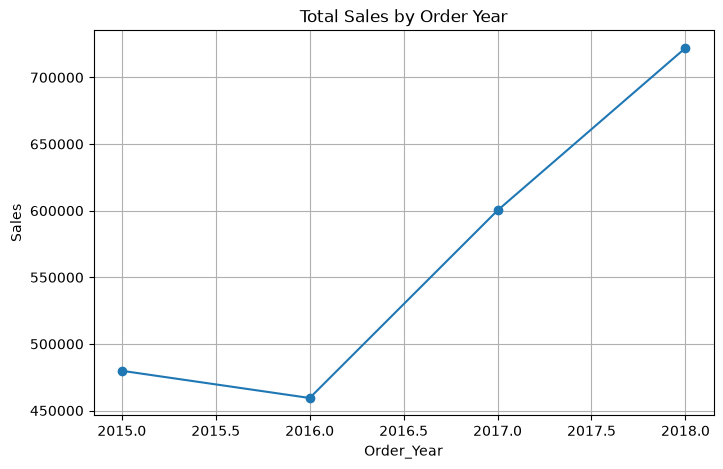

In [58]:

plt.figure(figsize=(8, 5))
plt.plot(year_summary["Order_Year"], year_summary["Total_Sales"], marker="o")

plt.title("Total Sales by Order Year")
plt.xlabel("Order_Year")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

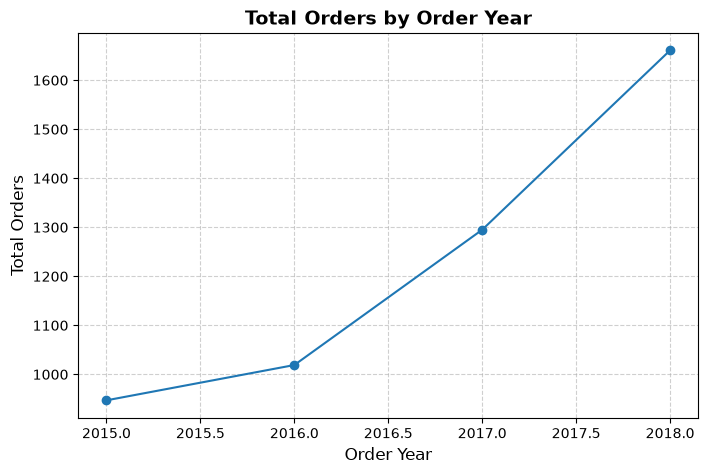

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(year_summary["Order_Year"], year_summary["Total_Orders"], marker="o", color="tab:blue")

# Add layout details
plt.title("Total Orders by Order Year", fontsize=14, fontweight="bold")
plt.xlabel("Order Year", fontsize=12)
plt.ylabel("Total Orders", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

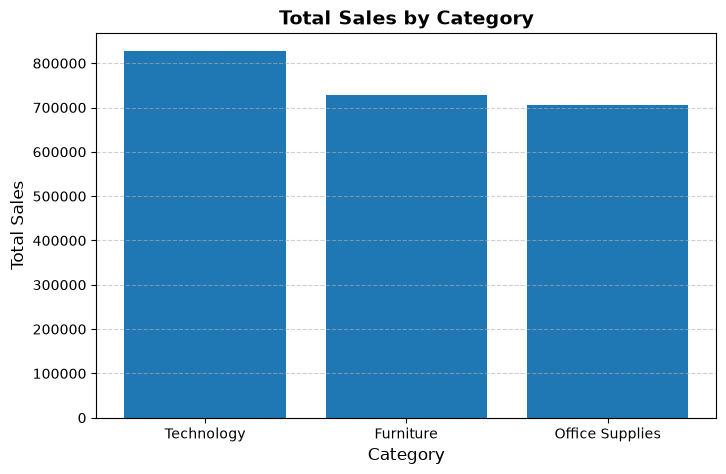

In [60]:
# ==========================================
# Visualization 3: Sales by Category
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    category_sales["Category"],
    category_sales["Total_Sales"],
    color="tab:blue"
)

plt.title("Total Sales by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

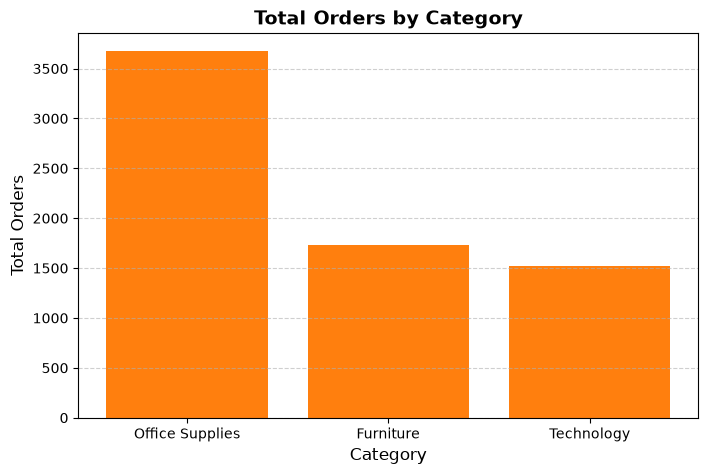

In [61]:
# ==========================================
# Total Orders by Category
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    category_orders["Category"],
    category_orders["Total_Orders"],
    color="tab:orange"
)

plt.title("Total Orders by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Orders", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

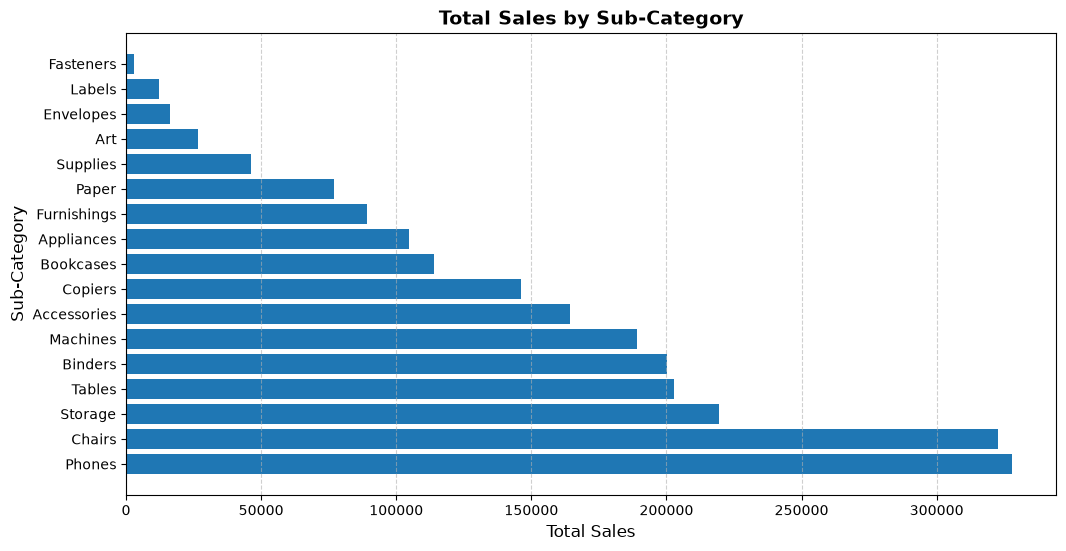

In [62]:
# ==========================================
# Total Sales by Sub-Category
# ==========================================

subcategory_plot = subcategory_sales.sort_values(
    "Total_Sales",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.barh(
    subcategory_plot["Sub-Category"],
    subcategory_plot["Total_Sales"],
    color="tab:blue"
)

plt.title("Total Sales by Sub-Category", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Sub-Category", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

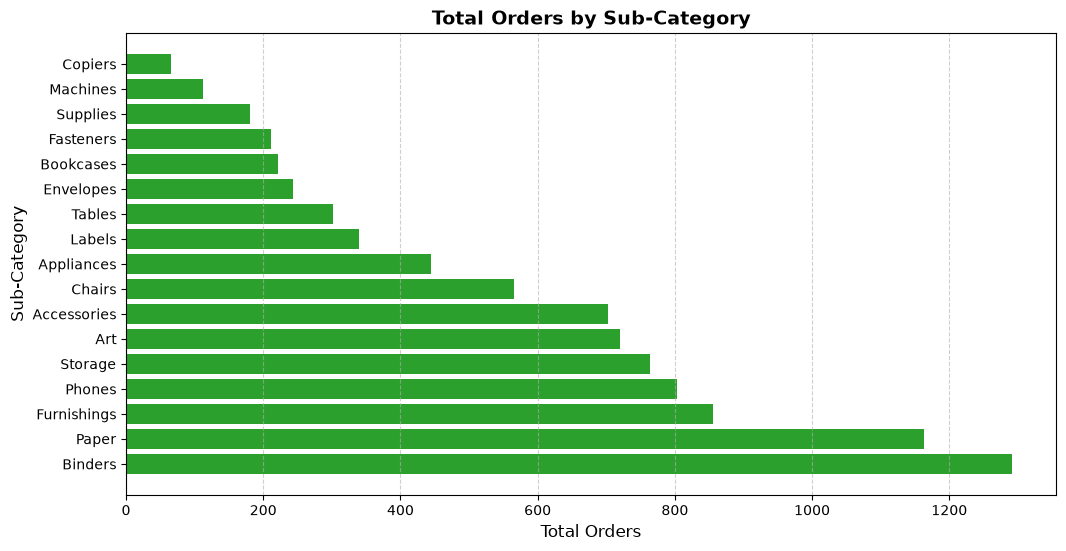

In [63]:
# ==========================================
# Total Orders by Sub-Category
# ==========================================

subcategory_orders_plot = subcategory_orders.sort_values(
    "Total_Orders",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.barh(
    subcategory_orders_plot["Sub-Category"],
    subcategory_orders_plot["Total_Orders"],
    color="tab:green"
)

plt.title("Total Orders by Sub-Category", fontsize=14, fontweight="bold")
plt.xlabel("Total Orders", fontsize=12)
plt.ylabel("Sub-Category", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

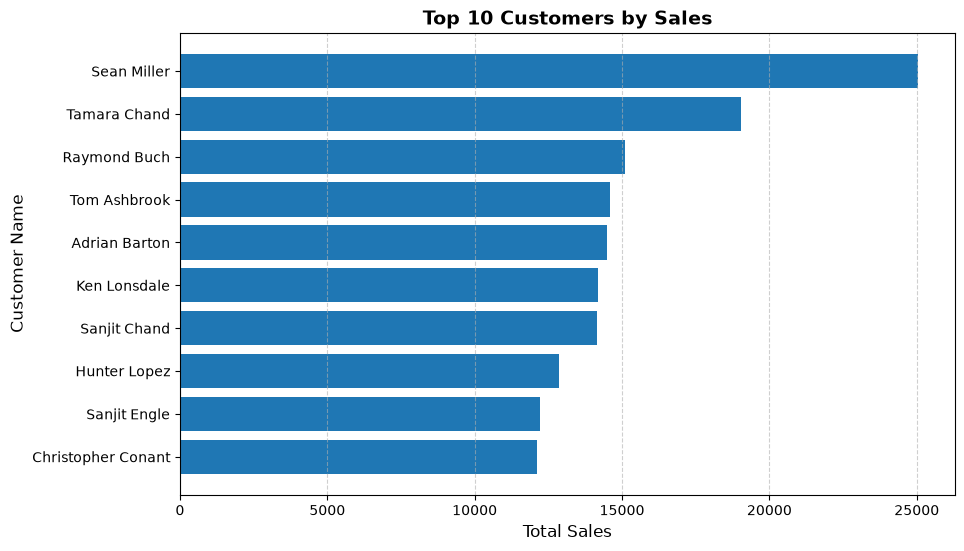

In [64]:
# ==========================================
# Top 10 Customers by Sales
# ==========================================

customer_summary = pd.merge(
    top_customers_sales,
    top_customers_orders,
    on=["Customer_ID", "Customer_Name"]
)

top10_customers = customer_summary.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10_customers["Customer_Name"],
    top10_customers["Total_Sales"],
    color="tab:blue"
)

plt.title("Top 10 Customers by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Customer Name", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.gca().invert_yaxis()

plt.show()

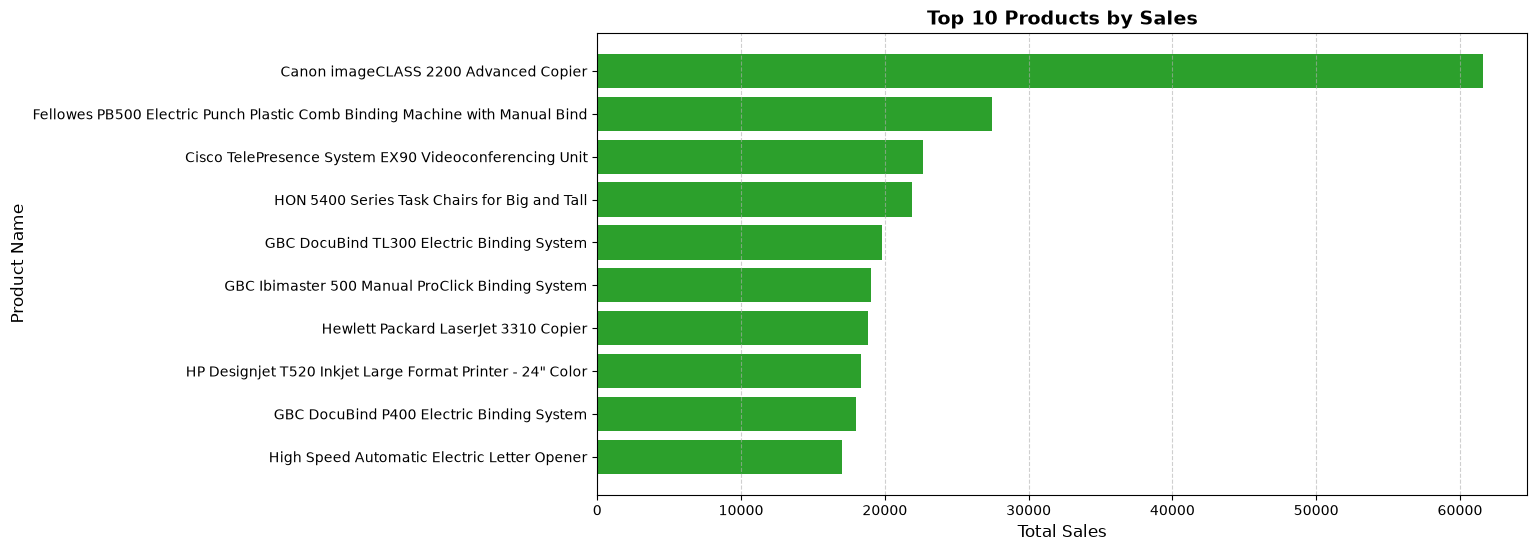

In [65]:
# ==========================================
# Top 10 Products by Sales
# ==========================================

top10_products = product_summary.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10_products["Product_Name"],
    top10_products["Total_Sales"],
    color="tab:green"
)

plt.title("Top 10 Products by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Product Name", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.gca().invert_yaxis()

plt.show()

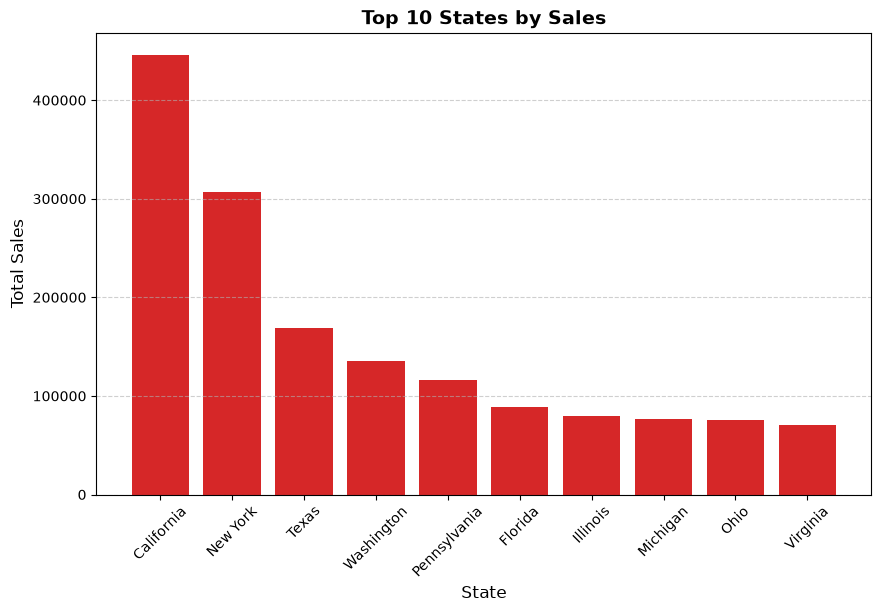

In [66]:
# ==========================================
# Top 10 States by Sales
# ==========================================

top10_states = state_summary.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10_states["State"],
    top10_states["Total_Sales"],
    color="tab:red"
)

plt.title("Top 10 States by Sales", fontsize=14, fontweight="bold")
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.xticks(rotation=45)

plt.show()

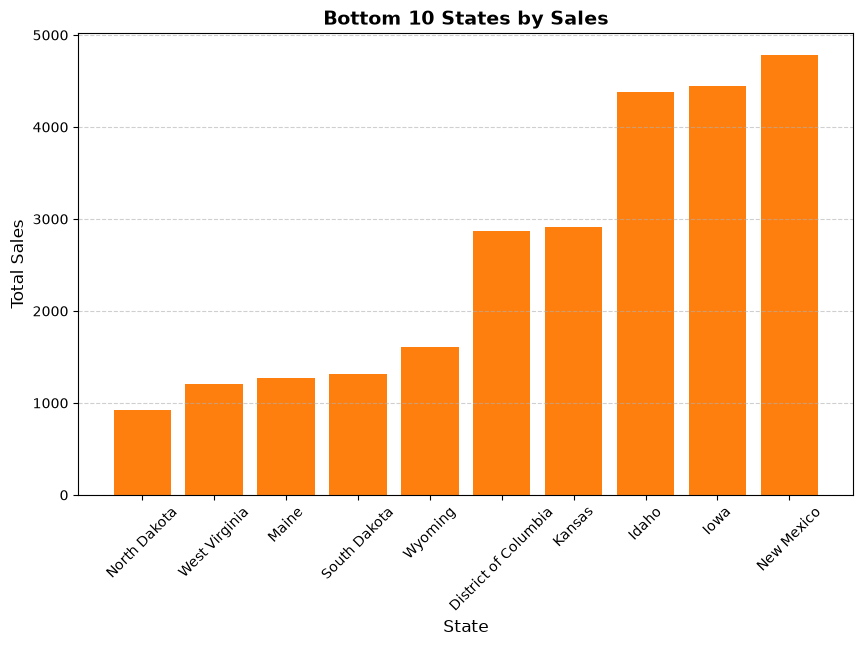

In [67]:
# ==========================================
# Bottom 10 States by Sales
# ==========================================

bottom10_states = state_summary.sort_values(
    "Total_Sales",
    ascending=True
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    bottom10_states["State"],
    bottom10_states["Total_Sales"],
    color="tab:orange"
)

plt.title("Bottom 10 States by Sales", fontsize=14, fontweight="bold")
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.xticks(rotation=45)

plt.show()

==========================================
Region Analysis Visualizations
==========================================

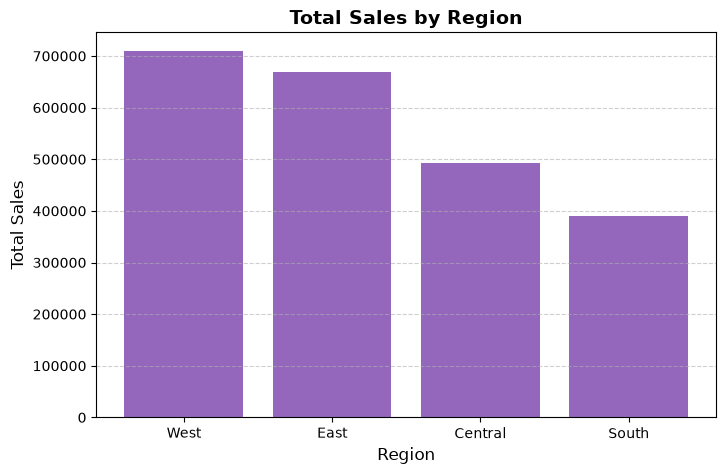

In [68]:
plt.figure(figsize=(8,5))

plt.bar(
    region_summary["Region"],
    region_summary["Total_Sales"],
    color="tab:purple"
)

plt.title("Total Sales by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

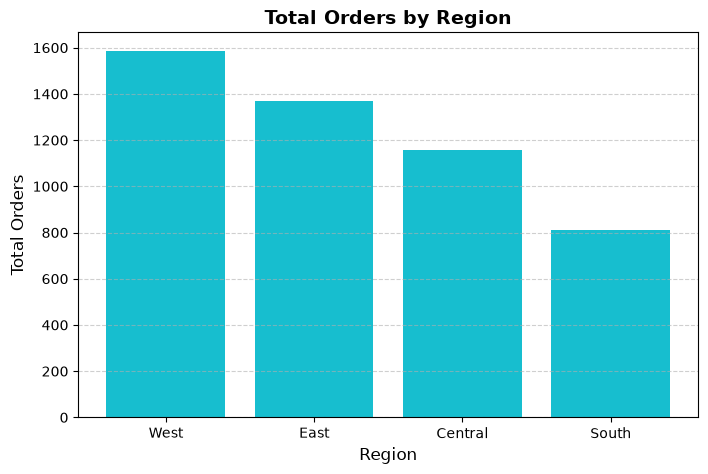

In [69]:
plt.figure(figsize=(8,5))

plt.bar(
    region_summary["Region"],
    region_summary["Total_Orders"],
    color="tab:cyan"
)

plt.title("Total Orders by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Orders", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

==========================================
Segment Analysis Visualizations
==========================================

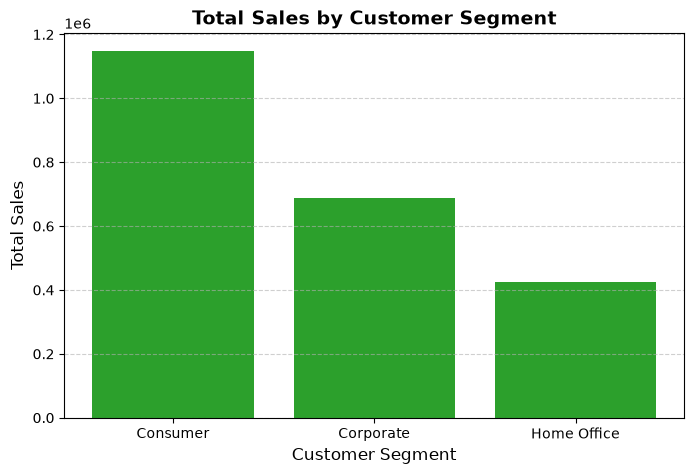

In [70]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_summary["Segment"],
    segment_summary["Total_Sales"],
    color="tab:green"
)

plt.title("Total Sales by Customer Segment", fontsize=14, fontweight="bold")
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

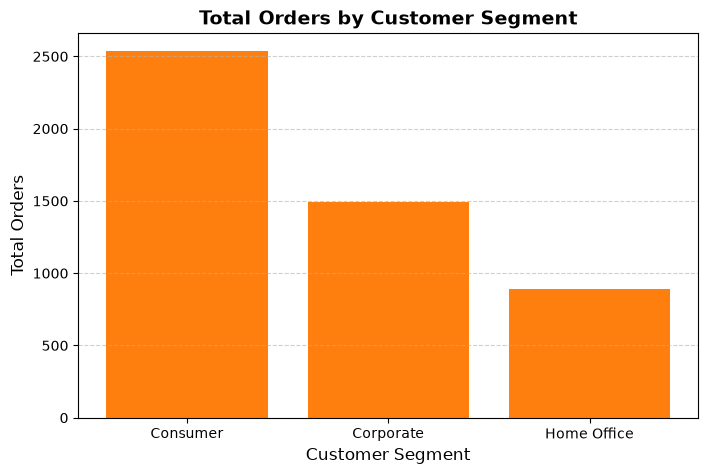

In [71]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_summary["Segment"],
    segment_summary["Total_Orders"],
    color="tab:orange"
)

plt.title("Total Orders by Customer Segment", fontsize=14, fontweight="bold")
plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Total Orders", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

==========================================
Shipping Analysis Visualizations
==========================================

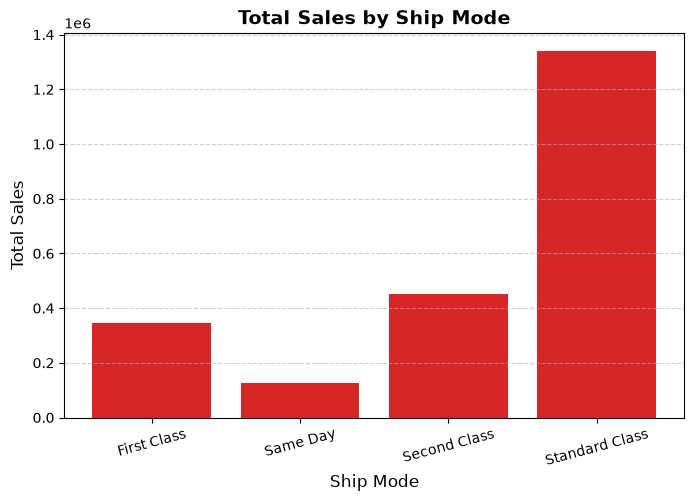

In [72]:
plt.figure(figsize=(8,5))

plt.bar(
    shipmode_summary["Ship_Mode"],
    shipmode_summary["Total_Sales"],
    color="tab:red"
)

plt.title("Total Sales by Ship Mode", fontsize=14, fontweight="bold")
plt.xlabel("Ship Mode", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.xticks(rotation=15)

plt.show()

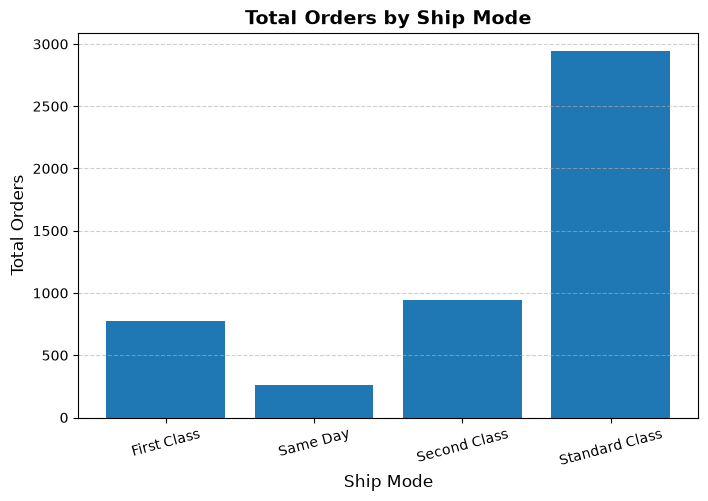

In [73]:
plt.figure(figsize=(8,5))

plt.bar(
    shipmode_summary["Ship_Mode"],
    shipmode_summary["Total_Orders"],
    color="tab:blue"
)

plt.title("Total Orders by Ship Mode", fontsize=14, fontweight="bold")
plt.xlabel("Ship Mode", fontsize=12)
plt.ylabel("Total Orders", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.xticks(rotation=15)

plt.show()

==========================================
Cross Analysis Visualizations
==========================================

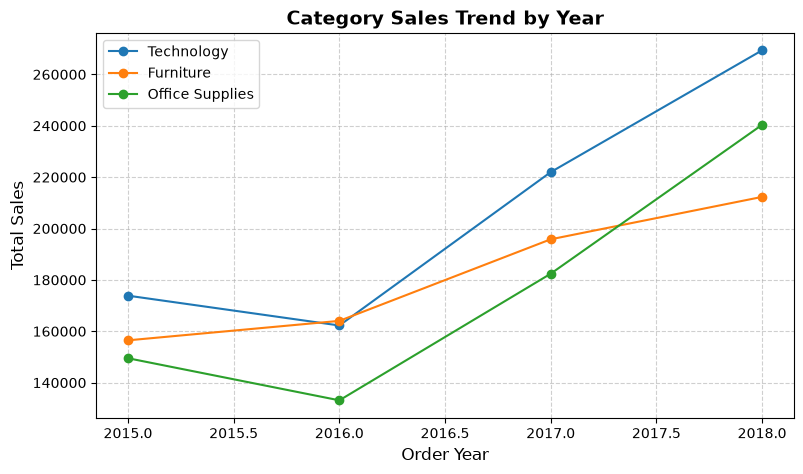

In [74]:
plt.figure(figsize=(9,5))

for category in category_year_summary["Category"].unique():
    data = category_year_summary[category_year_summary["Category"] == category]

    plt.plot(
        data["Order_Year"],
        data["Total_Sales"],
        marker="o",
        label=category
    )

plt.title("Category Sales Trend by Year", fontsize=14, fontweight="bold")
plt.xlabel("Order Year", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()

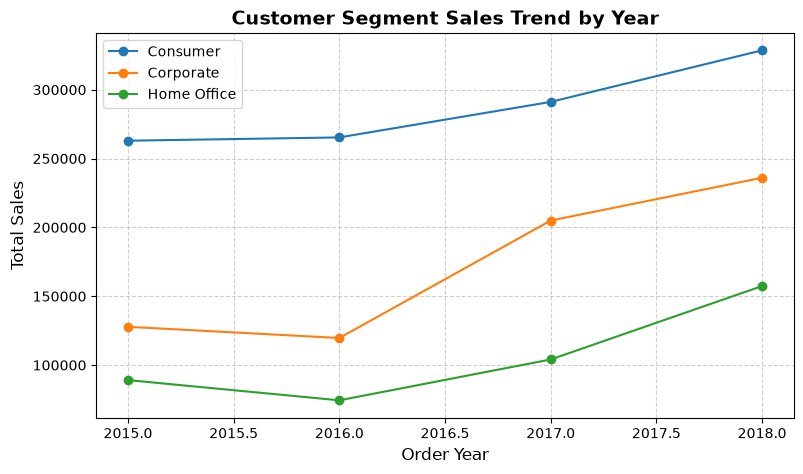

In [75]:
plt.figure(figsize=(9,5))

for segment in segment_year_summary["Segment"].unique():
    data = segment_year_summary[segment_year_summary["Segment"] == segment]

    plt.plot(
        data["Order_Year"],
        data["Total_Sales"],
        marker="o",
        label=segment
    )

plt.title("Customer Segment Sales Trend by Year", fontsize=14, fontweight="bold")
plt.xlabel("Order Year", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()

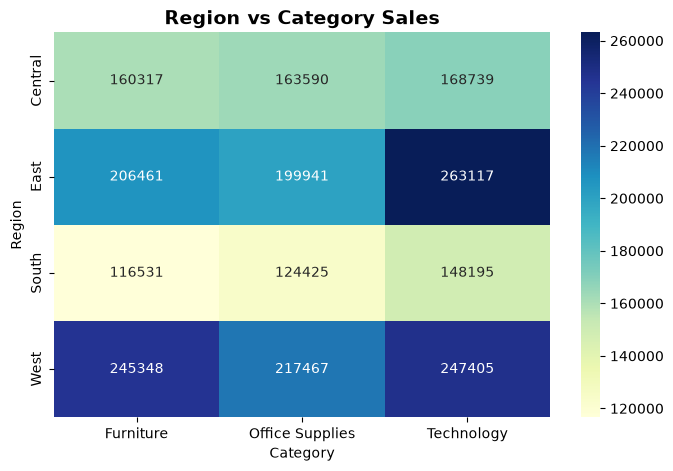

In [76]:
import seaborn as sns

pivot_region_category = region_category_summary.pivot(
    index="Region",
    columns="Category",
    values="Total_Sales"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_region_category,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Region vs Category Sales", fontsize=14, fontweight="bold")

plt.show()

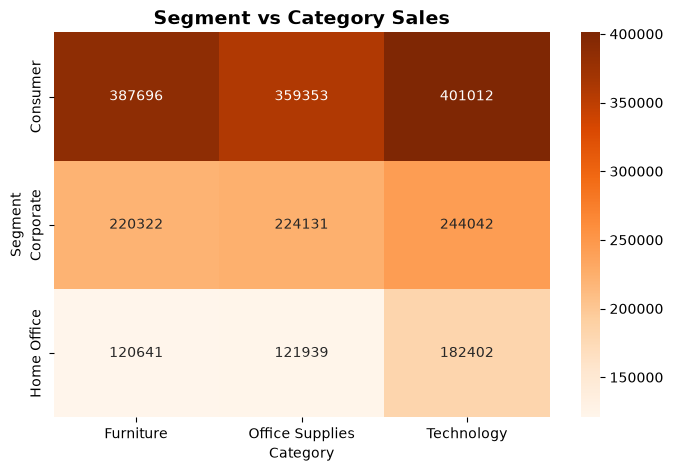

In [77]:
pivot_segment_category = segment_category_summary.pivot(
    index="Segment",
    columns="Category",
    values="Total_Sales"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot_segment_category,
    annot=True,
    fmt=".0f",
    cmap="Oranges"
)

plt.title("Segment vs Category Sales", fontsize=14, fontweight="bold")

plt.show()

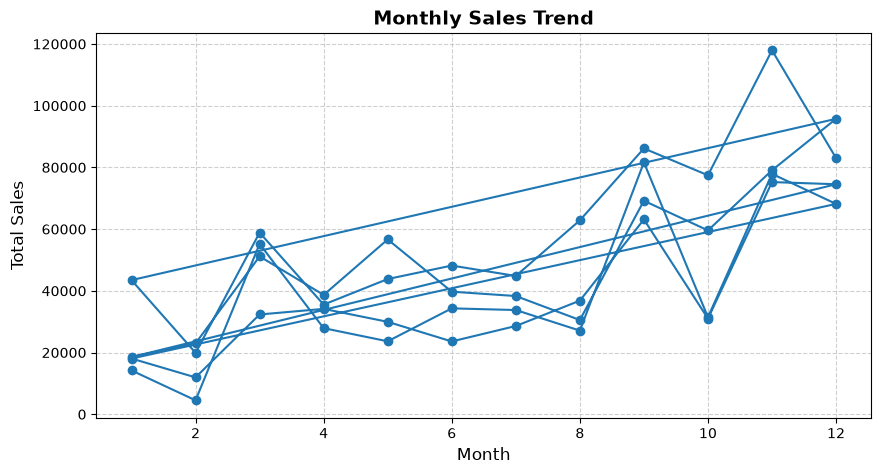

In [78]:
plt.figure(figsize=(10,5))

plt.plot(
    month_summary["Order_Month"],
    month_summary["Total_Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

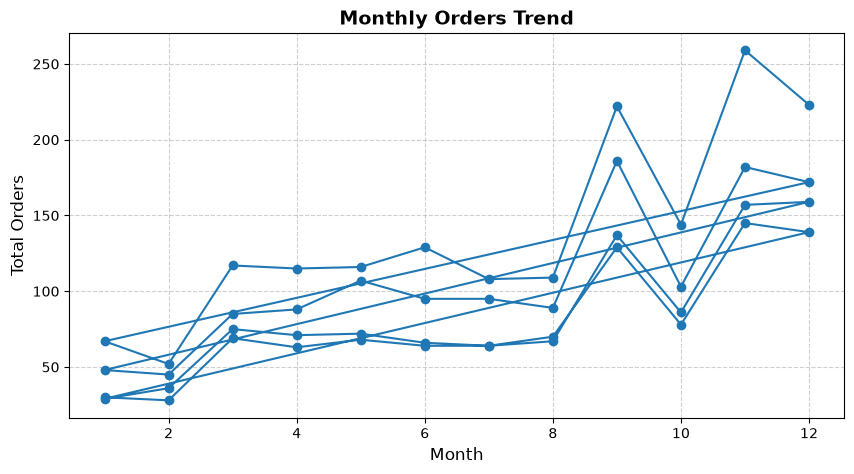

In [79]:
plt.figure(figsize=(10,5))

plt.plot(
    month_summary["Order_Month"],
    month_summary["Total_Orders"],
    marker="o"
)

plt.title("Monthly Orders Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Orders", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

==========================================
Correlation Analysis
==========================================

In [80]:
# ==========================================
# Correlation Matrix
# ==========================================

correlation_data = pd.DataFrame(
    {
        "Sales": df["Sales"],
        "Shipping_Days": df["Shipping_Days"],
        "Order_Year": df["Order_Year"],
        "Order_Month": df["Order_Month"],
        "Order_Quarter": df["Order_Quarter"],
        "Order_DayOfWeek": df["Order_Date"].dt.dayofweek,
        "Is_Weekend": df["Is_Weekend"],
    }
)

correlation_data.corr()

,Sales,Shipping_Days,Order_Year,Order_Month,Order_Quarter,Order_DayOfWeek,Is_Weekend
Sales,1.000000,-0.005712,-0.010624,-0.000134,-0.001434,0.001575,-0.001544
Shipping_Days,-0.005712,1.000000,-0.024498,0.000210,0.004716,0.019811,0.008937
Order_Year,-0.010624,-0.024498,1.000000,-0.018278,-0.018515,0.039054,0.001729
Order_Month,-0.000134,0.000210,-0.018278,1.000000,0.969299,0.035321,0.025917
Order_Quarter,-0.001434,0.004716,-0.018515,0.969299,1.000000,0.036290,0.027317
Order_DayOfWeek,0.001575,0.019811,0.039054,0.035321,0.036290,1.000000,0.848736
Is_Weekend,-0.001544,0.008937,0.001729,0.025917,0.027317,0.848736,1.000000


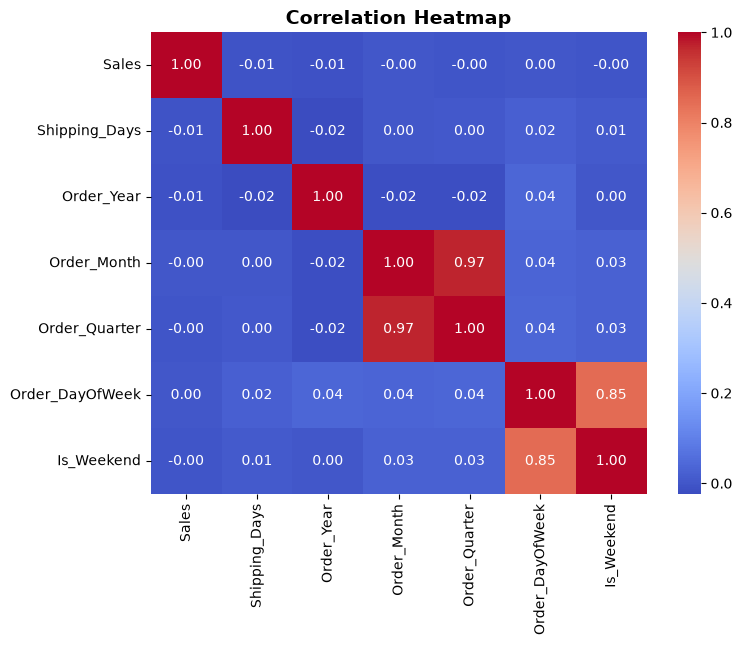

In [81]:
# ==========================================
# Correlation Heatmap
# ==========================================

import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")

plt.show()